# Exploratory Data Analysis

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
import time

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## Multi‑Source Social Feedback of Online News Feeds

Nuno Moniz & Luís Torgo (2018)  
**Dataset**: https://arxiv.org/abs/1801.07055

This dataset contains news articles collected from multiple official media outlets, enriched with metadata and social engagement metrics from three major platforms: Facebook, Google+, and LinkedIn.
It is commonly used for studying news popularity prediction, content virality, and cross‑platform engagement modeling.

#### Variables

##### Metadata

- **IDLink (numeric)**: Unique identifier of news items
- **Headline (string)**: Headline of the news item according to the official media sources
- **Source (string)**: Original news outlet that published the news item
- **Topic (string)**: Query topic used to obtain the items in the official media sources
- **PublishDate (timestamp)**: Date and time of the news items' publication

##### Sentiment Features

- **SentimentTitle (numeric)**: Sentiment score of the text in the news items' title
- **SentimentHeadline (numeric)**: Sentiment score of the text in the news items' headline

##### Social Engagement

- **Facebook (numeric)**: Final value of the news items' popularity according to the social media source Facebook
- **GooglePlus (numeric)**: Final value of the news items' popularity according to the social media source Google+
- **LinkedIn (numeric)**: Final value of the news items' popularity according to the social media source LinkedIn

#### Problem Definition

**Goal**: Predict the popularity of online news based on text and metadata.
This supports applications such as content optimization, targeted advertising, and recommendation systems.

Task Type: Supervised learning

Two‑stage modeling pipeline:

1) Classification — Identify whether a news item is viral
2) Regression — Predict the exact engagement level for viral items

#### Models 
##### Baseline Models
- Linear Regression
- Logistic Regression

##### Boosting Models
- LightGBM (TF‑IDF + metadata)
- LightGBM (embeddings + metadata)

##### NLP Models
- BERT + numeric features → classifier (is_viral)
- BERT + numeric features → regressor (for viral items only)

In [2]:
# Load dataset
df = pd.read_csv("data/Data/News_Final.csv")
df.set_index("IDLink", inplace=True)

In [3]:
# Make a safe copy to avoid SettingWithCopyWarning
df = df.copy()

## 1. Description of the Data Structure

In [4]:
df.head()

,Title,Headline,Source,Topic,PublishDate,SentimentTitle,SentimentHeadline,Facebook,GooglePlus,LinkedIn
IDLink,,,,,,,,,,
99248.0,Obama Lays Wreath at Arlington National Cemetery,Obama Lays Wreath at Arlington National Cemete...,USA TODAY,obama,2002-04-02 00:00:00,0.000000,-0.053300,-1,-1,-1
10423.0,A Look at the Health of the Chinese Economy,"Tim Haywood, investment director business-unit...",Bloomberg,economy,2008-09-20 00:00:00,0.208333,-0.156386,-1,-1,-1
18828.0,Nouriel Roubini: Global Economy Not Back to 2008,"Nouriel Roubini, NYU professor and chairman at...",Bloomberg,economy,2012-01-28 00:00:00,-0.425210,0.139754,-1,-1,-1
27788.0,Finland GDP Expands In Q4,Finland's economy expanded marginally in the t...,RTT News,economy,2015-03-01 00:06:00,0.000000,0.026064,-1,-1,-1
27789.0,"Tourism, govt spending buoys Thai economy in J...",Tourism and public spending continued to boost...,The Nation - Thailand&#39;s English news,economy,2015-03-01 00:11:00,0.000000,0.141084,-1,-1,-1


In [5]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df.iloc[[999]]

,Title,Headline,Source,Topic,PublishDate,SentimentTitle,SentimentHeadline,Facebook,GooglePlus,LinkedIn
IDLink,,,,,,,,,,
533.0,Microsoft to acquire data protection firm Secure Islands,"Microsoft announced Monday that it has made a deal to acquire Secure Islands, an Israeli company that focuses on protecting companies' data. Neither company disclosed the terms of the deal.",MIS Asia,microsoft,2015-11-10 01:56:00,-0.003683,0.045644,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93239 entries, 99248.0 to 61870.0
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              93239 non-null  object 
 1   Headline           93224 non-null  object 
 2   Source             92960 non-null  object 
 3   Topic              93239 non-null  object 
 4   PublishDate        93239 non-null  object 
 5   SentimentTitle     93239 non-null  float64
 6   SentimentHeadline  93239 non-null  float64
 7   Facebook           93239 non-null  int64  
 8   GooglePlus         93239 non-null  int64  
 9   LinkedIn           93239 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 7.8+ MB


In [7]:
df.describe(include='all')

,Title,Headline,Source,Topic,PublishDate,SentimentTitle,SentimentHeadline,Facebook,GooglePlus,LinkedIn
count,93239,93224,92960,93239,93239,93239.000000,93239.000000,93239.000000,93239.000000,93239.000000
unique,81259,86694,5756,4,82644,NaN,NaN,NaN,NaN,NaN
top,Business Highlights,Read full story for latest details.,Bloomberg,economy,2016-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN
freq,37,18,1732,33928,112,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,-0.005411,-0.027493,113.141336,3.888362,16.547957
std,NaN,NaN,NaN,NaN,NaN,0.136431,0.141964,620.173233,18.492648,154.459048
min,NaN,NaN,NaN,NaN,NaN,-0.950694,-0.755433,-1.000000,-1.000000,-1.000000
25%,NaN,NaN,NaN,NaN,NaN,-0.079057,-0.114574,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,0.000000,-0.026064,5.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,0.064255,0.059709,33.000000,2.000000,4.000000


In [9]:
df['Topic'].value_counts(normalize=True)

Topic
economy      0.363882
obama        0.306846
microsoft    0.234430
palestine    0.094842
Name: proportion, dtype: float64

## 2. Analysis of Target Variable Distribution
In this section, we analyze the distribution of the target variables used in the project.
The dataset contains three continuous engagement metrics (Facebook, GooglePlus, LinkedIn).
Understanding their distribution is essential for selecting appropriate preprocessing steps, modeling strategies, and evaluation metrics.

In [16]:
targets = ['Facebook', 'GooglePlus', 'LinkedIn']

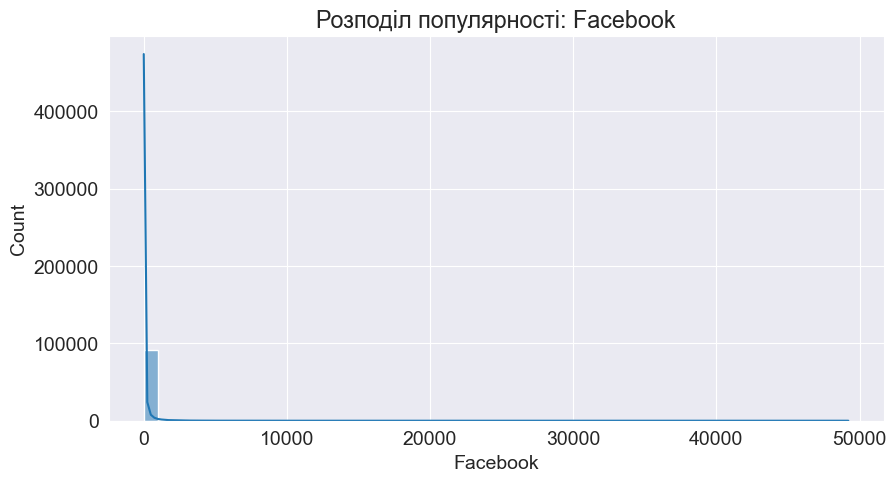

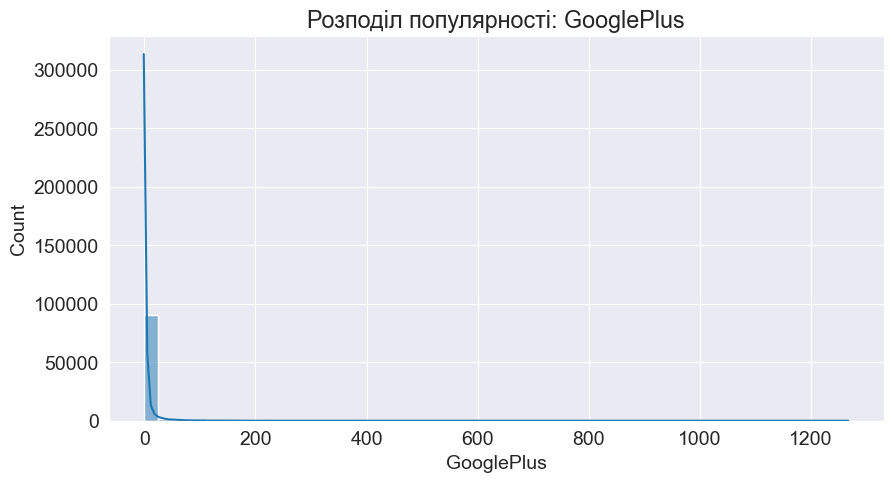

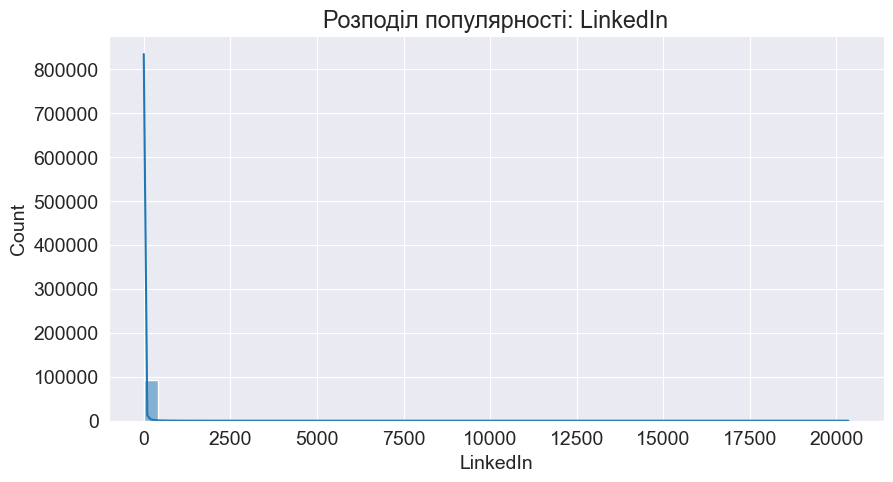

In [17]:
for col in targets:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Розподіл популярності: {col}")
    plt.show()

In [18]:
(df[['Facebook', 'GooglePlus', 'LinkedIn']] == -1).sum()

Facebook      11602
GooglePlus     5744
LinkedIn       5745
dtype: int64

In [19]:
((df[['Facebook', 'GooglePlus', 'LinkedIn']] == -1).sum() / len(df)) * 100

Facebook      12.443291
GooglePlus     6.160512
LinkedIn       6.161585
dtype: float64

### Key Observations
The engagement metrics contain many zeros and a long tail of very large values.
Only a small percentage of news items can be considered viral, resulting in a highly imbalanced classification target.
Such skewed distributions can negatively impact model performance if left untreated.

#### Possible Preprocessing Strategy
To stabilize variance and reduce the impact of extreme outliers, a log‑transformation can be applied

## 3. Missing Values and Outliers

In [10]:
df.isna().sum().sort_values(ascending=False)

Source               279
Headline              15
Title                  0
Topic                  0
PublishDate            0
SentimentTitle         0
SentimentHeadline      0
Facebook               0
GooglePlus             0
LinkedIn               0
dtype: int64

In [20]:
# Порожні текстові поля
(df[['Title','Headline','Source']] == "").sum()

Title       0
Headline    0
Source      0
dtype: int64

In [23]:
df['Title'].str.strip().eq("").sum()

np.int64(0)

In [24]:
df['Headline'].str.strip().eq("").sum()

np.int64(5)

In [25]:
df['Source'].str.strip().eq("").sum()

np.int64(70)

In [26]:
df[df['Source'].str.strip() == ""].head()

,Title,Headline,Source,Topic,PublishDate,SentimentTitle,SentimentHeadline,Facebook,GooglePlus,LinkedIn
IDLink,,,,,,,,,,
63287.0,Palestine: The open wound,"Comment: The historical injustice against Palestine is the cause of violence - and only by restoring Palestinian rights will the violence end, argues Ali Anouzla.",,palestine,2015-10-27 12:18:00,-0.229167,-0.074279,-1,-1,-1
63189.0,Good reception: Palestinian 3G and the economic peace plan,"Analysis: Israel and Palestine have come to an agreement on building a 3G mobile network, in what may be part of a peace quartet initiative.",,palestine,2015-11-23 11:33:00,-0.070312,-0.237500,1,0,0
63636.0,Palestine advocacy group fights closure of UK bank accounts,"Blog: After closing the accounts of a number of British pro-Palestinian activist groups, the Co-op bank is now facing legal action launched by The Palestine Solidarity Campaign.",,palestine,2015-11-25 06:56:00,0.125000,-0.092848,7,1,0
65277.0,The UN's Palestine logic: Solidarity after partition,"Comment: The United Nations makes up ways to 'remember' Palestinian rights, while undermining them at every step, writes Ramona Wadi.",,palestine,2015-12-03 22:00:00,0.000000,0.023292,13,1,1
65278.0,Village people: Surviving in Palestine's Area C,"Analysis: Israel's zoning of urban areas under its military occupation is heavily weighted to benefit Israeli settlers at the expense of Palestinian villagers, notes Ron Taylor.",,palestine,2015-12-03 22:26:00,0.000000,-0.098058,26,0,0


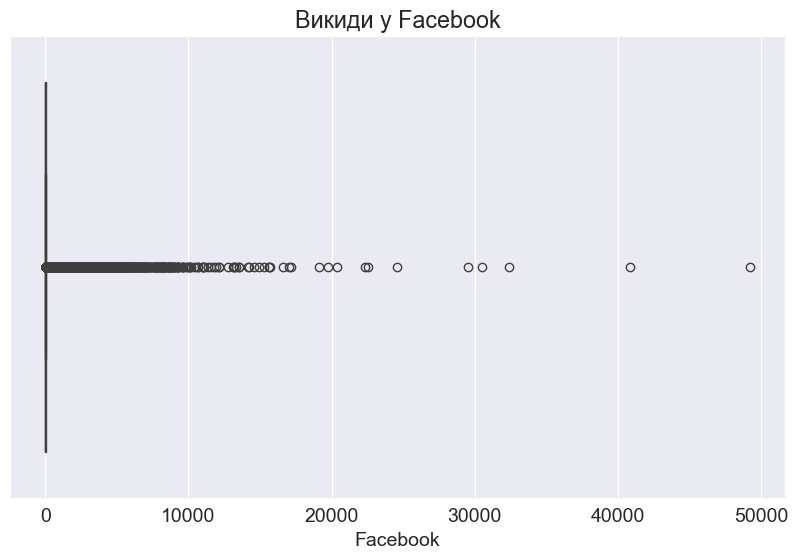

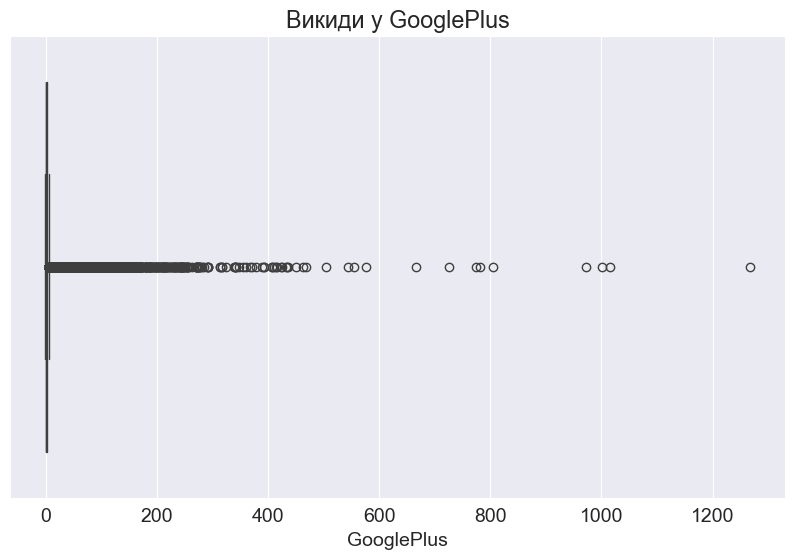

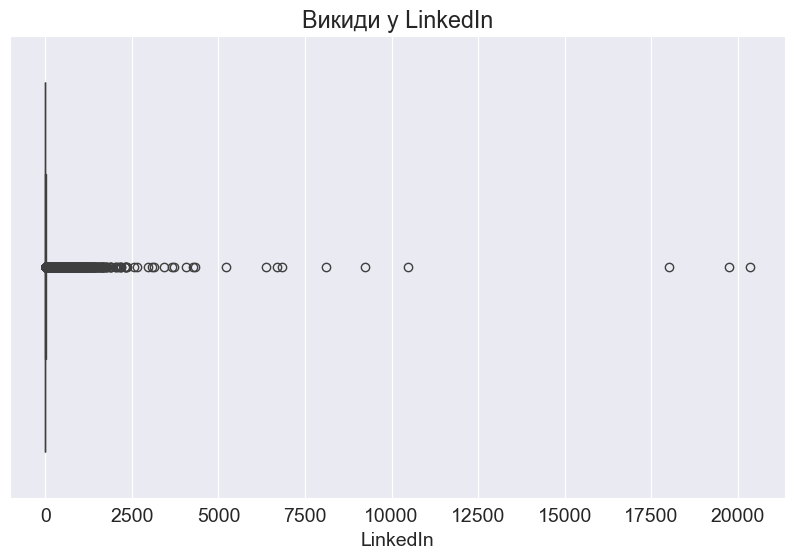

In [11]:
# Викиди у таргетах
for col in targets:
    sns.boxplot(x=df[col])
    plt.title(f"Викиди у {col}")
    plt.show()

In [27]:
df = df.dropna(subset=['Source', 'Headline'])

In [12]:
df.duplicated().sum()

np.int64(4)

## 4. Visualization of Key Patterns

In [13]:
df.columns

Index(['Title', 'Headline', 'Source', 'Topic', 'PublishDate', 'SentimentTitle',
       'SentimentHeadline', 'Facebook', 'GooglePlus', 'LinkedIn'],
      dtype='object')

### 📈 Графік 1 — Залежність популярності від тональності заголовка

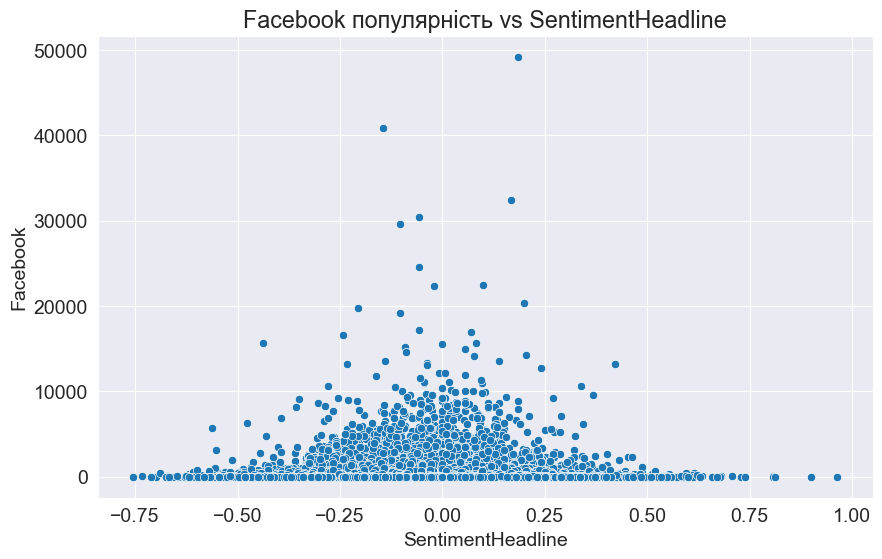

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='SentimentHeadline', y='Facebook')
plt.title("Facebook популярність vs SentimentHeadline")
plt.show()

Інтерпретація:
негативні заголовки часто отримують більше реакцій
тональність може бути важливою фічею

### 📈 Графік 2 — Популярність за темами (Topic)

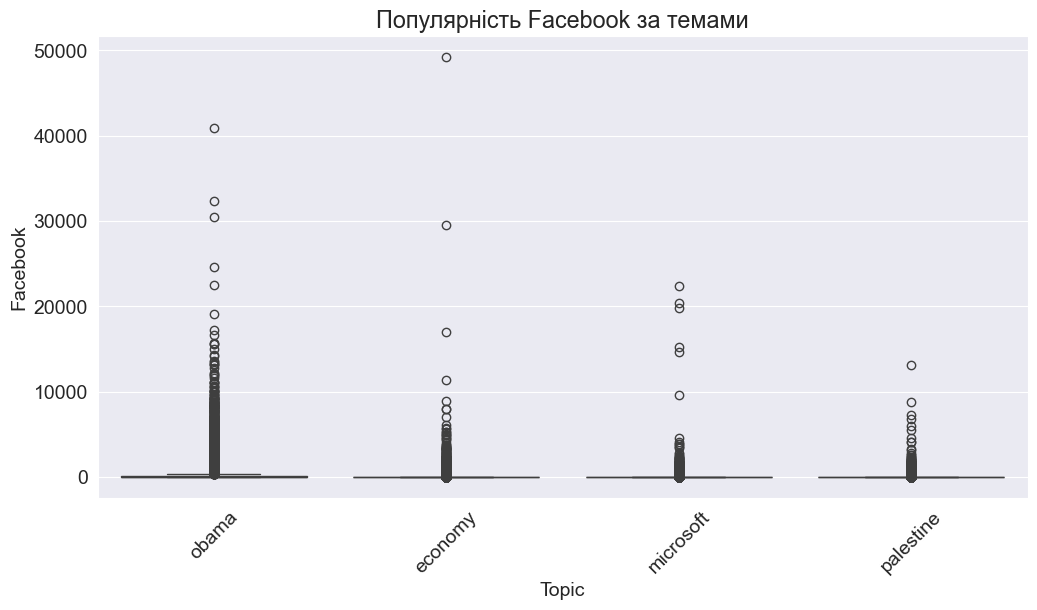

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Topic', y='Facebook')
plt.xticks(rotation=45)
plt.title("Популярність Facebook за темами")
plt.show()

Теми “obama”, “economy”, “microsoft”, “palestine” мають різний рівень популярності

## 2.5. Аналіз текстових фіч

### Довжина текстів

In [27]:
df['title_len'] = df['Title'].str.len()
df['title_word_count'] = df['Title'].str.split().str.len()
df['headline_len'] = df['Headline'].str.len()
df['headline_word_count'] = df['Headline'].str.split().str.len()

df[['title_len', 'headline_len','title_word_count', 'headline_word_count']].describe()

,title_len,headline_len,title_word_count,headline_word_count
count,93239.000000,93224.000000,93239.000000,93224.000000
mean,57.236543,164.700925,9.101996,26.530046
std,12.856534,71.680954,2.319440,11.694246
min,4.000000,1.000000,1.000000,0.000000
25%,50.000000,135.000000,8.000000,21.000000
50%,59.000000,140.000000,9.000000,23.000000
75%,66.000000,148.000000,11.000000,26.000000
max,170.000000,446.000000,24.000000,80.000000


### Розподіл довжини заголовків

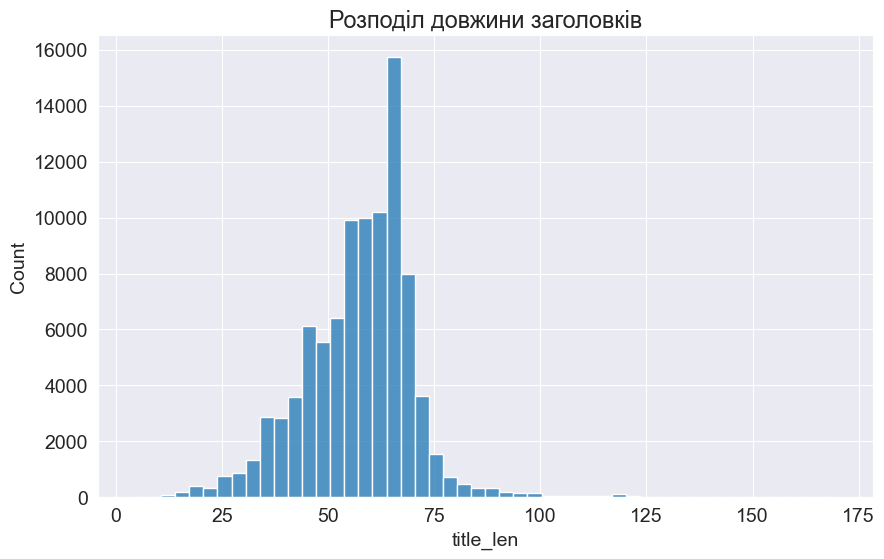

In [28]:
sns.histplot(df['title_len'], bins=50)
plt.title("Розподіл довжини заголовків")
plt.show()

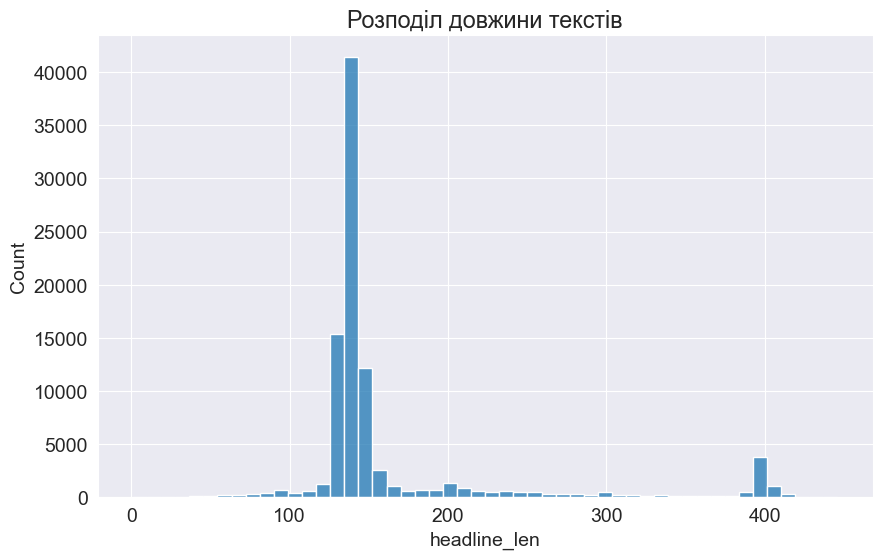

In [29]:
sns.histplot(df['headline_len'], bins=50)
plt.title("Розподіл довжини текстів")
plt.show()

## 2.6 Частотний аналіз слів

### CountVectorizer

In [31]:
eda_df = df.copy()

eda_df['Headline'] = eda_df['Headline'].fillna("").astype(str)
eda_df['Source'] = eda_df['Source'].fillna("").astype(str)

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', max_features=50)
cv.fit(eda_df['Headline'])

pd.DataFrame(cv.get_feature_names_out(), columns=['word'])

,word
0,10
1,2015
2,2016
3,according
4,administration
5,announced
6,bank
7,barack
8,business
9,china


In [39]:
cv = CountVectorizer(stop_words='english', max_features=20)
cv.fit(eda_df['Source'])

pd.DataFrame(cv.get_feature_names_out(), columns=['source'])

,word
0,blog
1,bloomberg
2,business
3,com
4,daily
5,finance
6,herald
7,insider
8,international
9,journal


### WordCloud

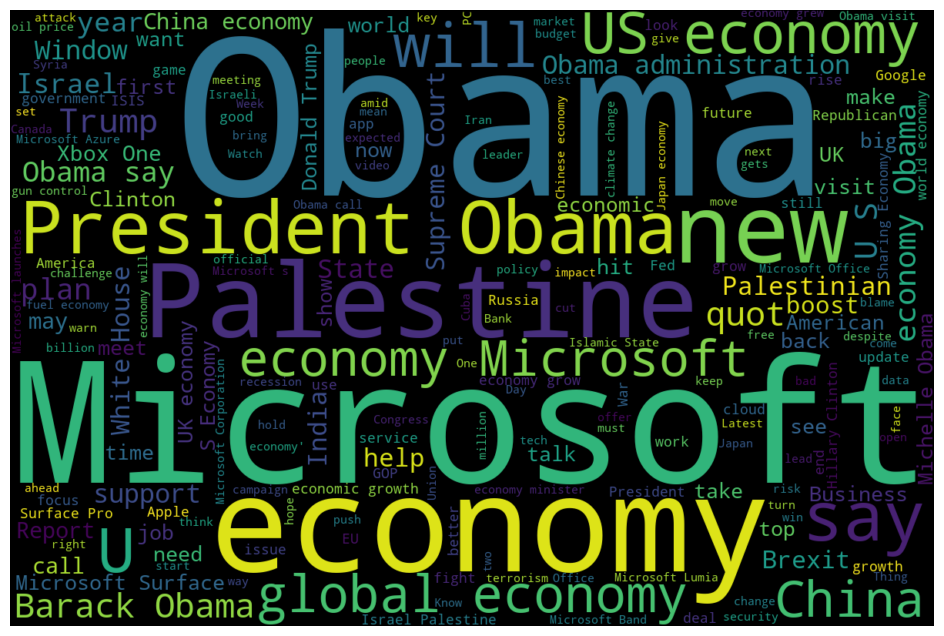

In [36]:
from wordcloud import WordCloud

text = " ".join(eda_df['Title'].tolist())
wc = WordCloud(width=1200, height=800).generate(text)
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

In [37]:
# WordCloud function
def plot_wordcloud(text, title):
    wc = WordCloud(
        width=1200,
        height=800,
        background_color="white",
        colormap="viridis"
    ).generate(text)

    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis("off")
    plt.show()

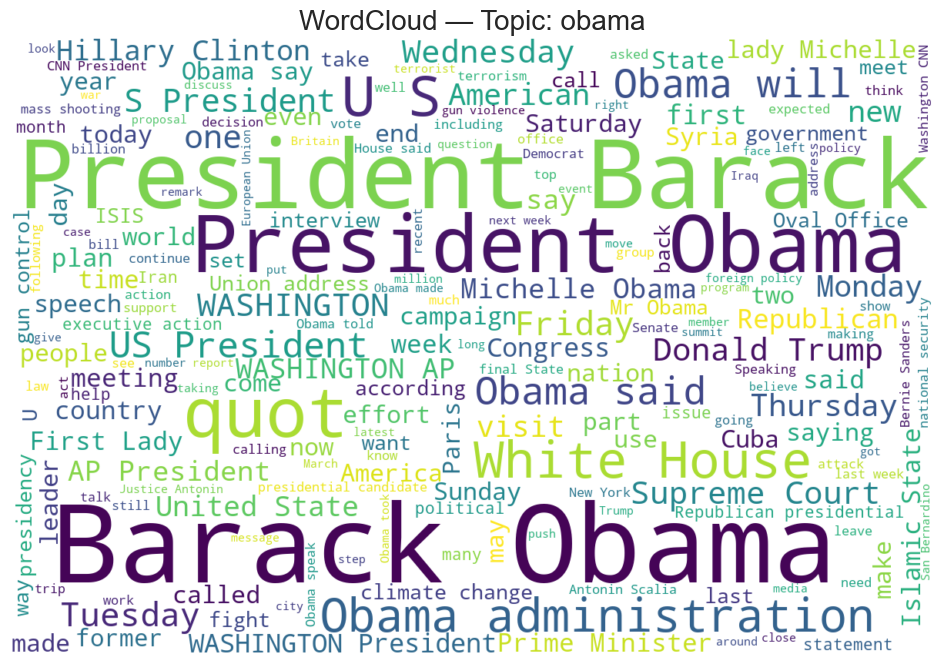

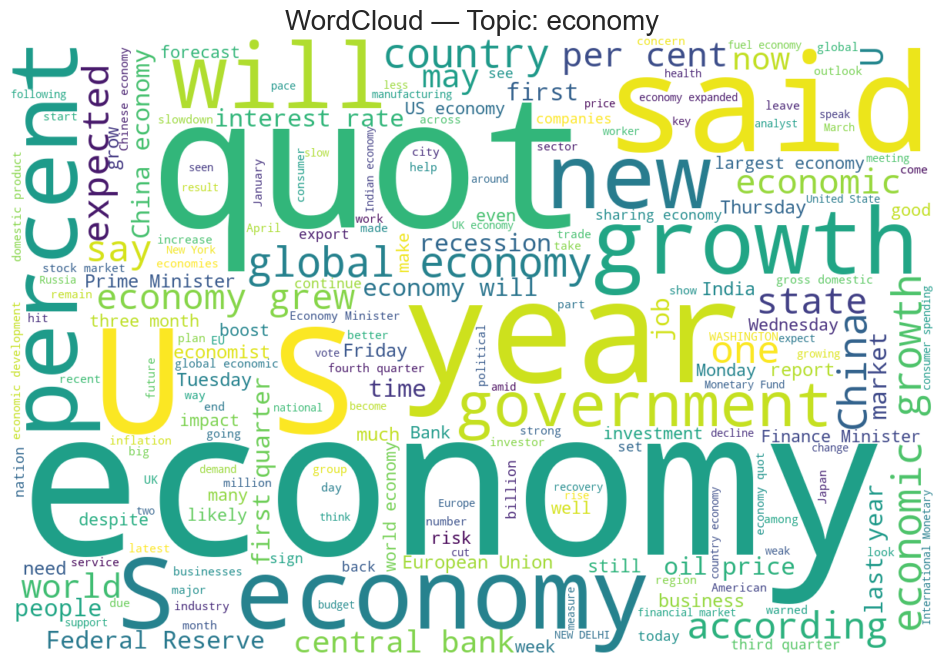

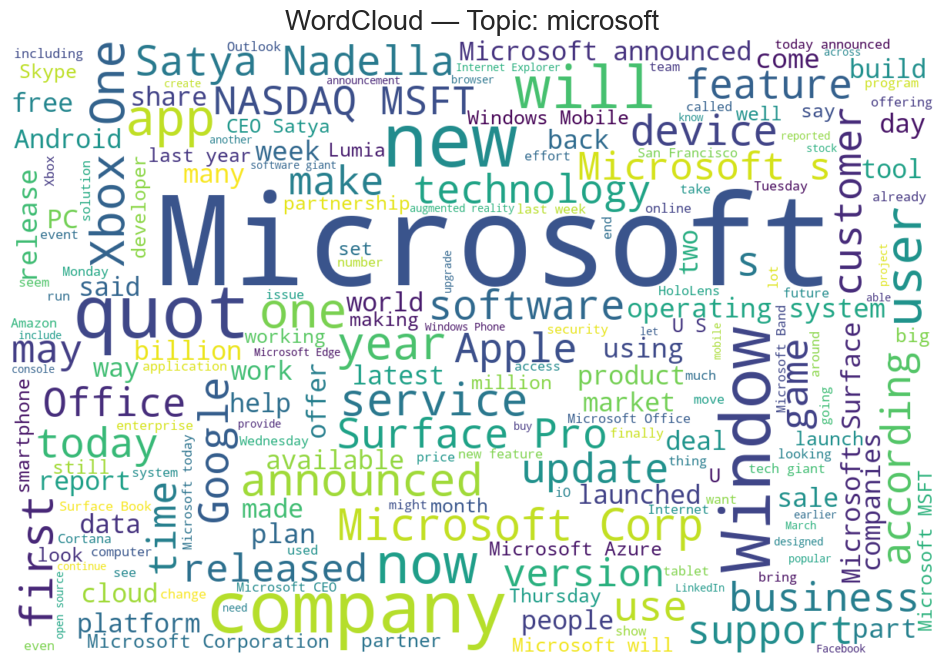

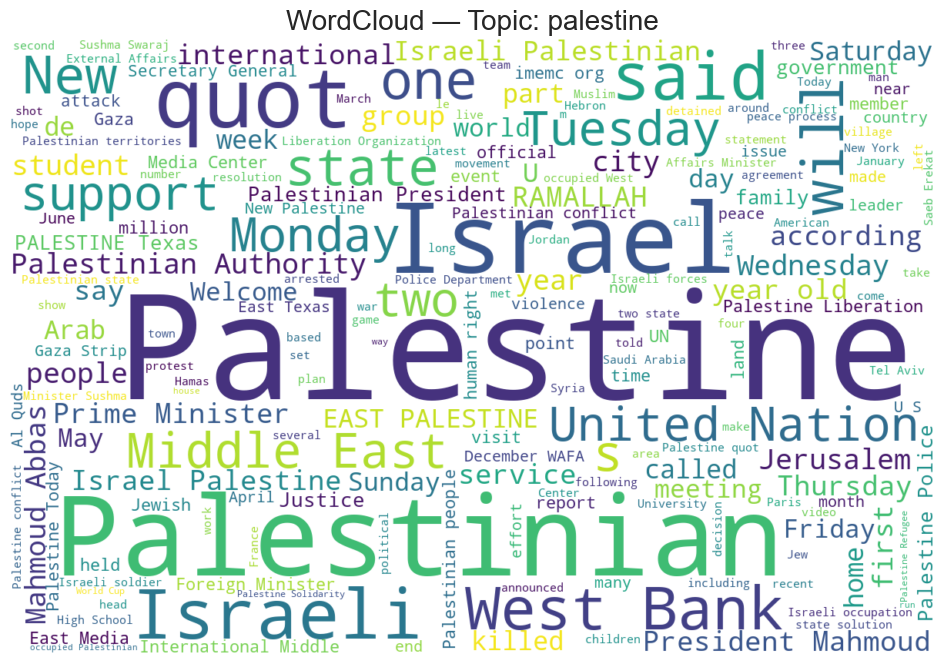

In [38]:
# WordCloud for each SentimentHeadline class
for topic in eda_df['Topic'].unique():
    subset = eda_df[eda_df['Topic'] == topic]
    text = " ".join(subset['Headline'].tolist())
    plot_wordcloud(text, f"WordCloud — Topic: {topic}")

## 2.7. Кореляції між фічами

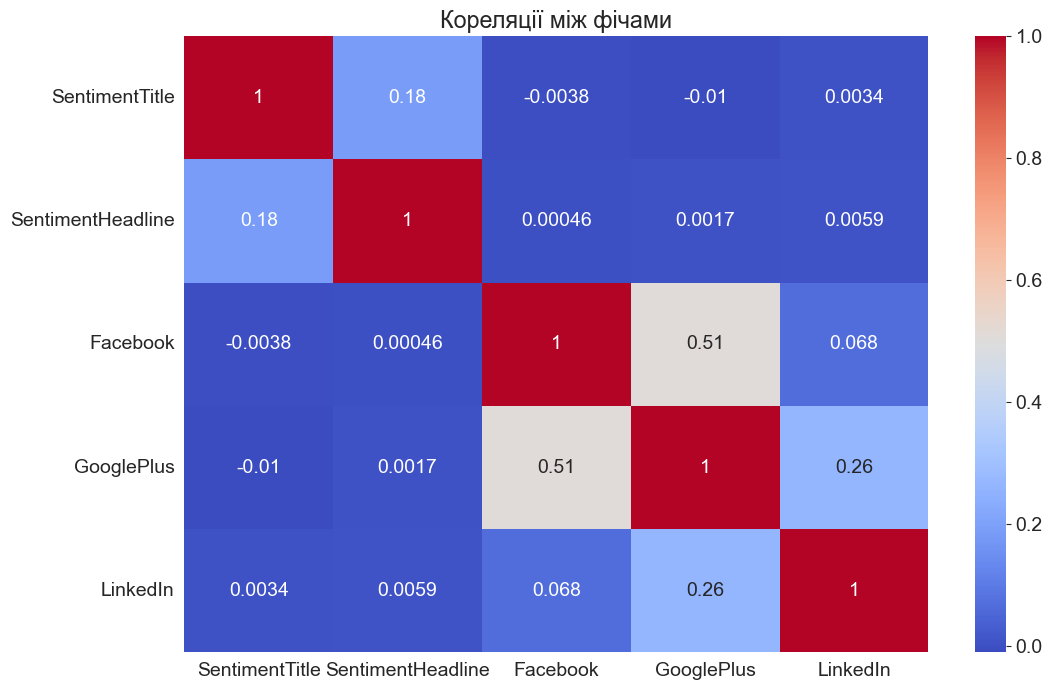

In [40]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[['SentimentTitle','SentimentHeadline','Facebook','GooglePlus','LinkedIn']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Кореляції між фічами")
plt.show()

## 2.8 Синтаксичний аналіз тексту

### Перевірка наявності HTML, сміття, спецсимволів

#### Перевірка HTML‑тегів

In [49]:
import re

pattern_html = re.compile(r"&[a-zA-Z]+;")

eda_df['Title_has_html'] = eda_df['Title'].str.contains(pattern_html)
eda_df['Headline_has_html'] = eda_df['Headline'].str.contains(pattern_html)

eda_df[['Title_has_html', 'Headline_has_html']].mean() * 100

Title_has_html       1.145443
Headline_has_html    9.333004
dtype: float64

#### Перевірка сміттєвих символів

In [44]:
pattern_garbage = re.compile(r"[^a-zA-Z0-9\s.,!?;:'\"()\-–—/%&@#]")

eda_df['Title_garbage'] = eda_df['Title'].str.contains(pattern_garbage)
eda_df['Headline_garbage'] = eda_df['Headline'].str.contains(pattern_garbage)

eda_df[['Title_garbage', 'Headline_garbage']].mean() * 100

Title_garbage       6.304229
Headline_garbage    8.868606
dtype: float64

#### Перевірка спецсимволів (#, @, %, &, *, { }, < >)

In [43]:
pattern_special = re.compile(r"[#@%&*{}<>]")

eda_df['Title_special'] = eda_df['Title'].str.contains(pattern_special)
eda_df['Headline_special'] = eda_df['Headline'].str.contains(pattern_special)

eda_df[['Title_special', 'Headline_special']].mean() * 100

Title_special        2.659831
Headline_special    11.228134
dtype: float64

#### Перевірка emoji

In [48]:
pattern_emoji = re.compile(r"[^\w\s.,!?;:'\"()\-–—/%&@#]")
eda_df['Title_emoji'] = eda_df['Title'].str.contains(pattern_emoji)
eda_df['Headline_emoji'] = eda_df['Headline'].str.contains(pattern_emoji)

eda_df[['Title_emoji', 'Headline_emoji']].mean() * 100

Title_emoji       6.236661
Headline_emoji    8.671264
dtype: float64

#### Перевірка спецсимволів (#, @, %, &, *, { }, < >)

In [51]:
pattern_url = re.compile(
    r"(https?://\S+|www\.\S+|\S+\.(com|org|net|info|biz|io|co|uk|pl|de|fr|ru|ua)\S*)"
)

eda_df['Title_has_url'] = eda_df['Title'].str.contains(pattern_url)
eda_df['Headline_has_url'] = eda_df['Headline'].str.contains(pattern_url)

eda_df[['Title_has_url', 'Headline_has_url']].mean() * 100

C:\Users\mariy\AppData\Local\Temp\ipykernel_25916\886900923.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eda_df['Title_has_url'] = eda_df['Title'].str.contains(pattern_url)
C:\Users\mariy\AppData\Local\Temp\ipykernel_25916\886900923.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eda_df['Headline_has_url'] = eda_df['Headline'].str.contains(pattern_url)


Title_has_url       0.095454
Headline_has_url    0.612405
dtype: float64

In [54]:
eda_df[eda_df['Headline_has_url']].head()

,Title,Headline,Source,Topic,PublishDate,SentimentTitle,SentimentHeadline,Facebook,GooglePlus,LinkedIn,title_len,title_word_count,headline_len,headline_word_count,Title_has_html,Headline_has_html,Title_garbage,Headline_garbage,Title_special,Headline_special,Title_emoji,Headlines_emoji,Headline_emoji,Title_has_url,Headline_has_url
IDLink,,,,,,,,,,,,,,,,,,,,,,,,,
27790.0,Intellitec Solutions to Host 13th Annual Spring Microsoft Dynamics User Group,"Over 100 attendees expected to see latest version of Microsoft Dynamics SL and Dynamics GP (PRWeb February 29, 2016) Read the full story at http://www.prweb.com/releases/2016/03/prweb13238571.htm",PRWeb,microsoft,2015-03-01 00:19:00,-0.075378,0.036773,-1,-1,-1,77,11,196.0,25.0,False,False,False,False,False,False,False,False,False,False,True
395.0,"Alphabet, Microsoft, Amazon give Wall Street reason to cheer","Google parent Alphabet Inc , Microsoft Corp and Amazon.com Inc made headway in the latest quarter in the areas that will be their main engines of growth for years to come, driving up shares across the tech sector on Friday. For Alphabet, search traffic on mobiles surpassed desktop traffic worldwide for the first time, while Amazon was able to boost margins, an area of concern, as its cloud",Reuters via Yahoo! News,microsoft,2015-10-23 08:09:00,0.093403,0.039686,-1,-1,-1,60,9,393.0,68.0,False,False,False,False,False,False,False,False,False,False,True
416.0,"Alphabet, Microsoft, Amazon give Wall Street reason to cheer","Google parent Alphabet Inc, Microsoft Corp and Amazon.com Inc made headway in the latest quarter in the areas that will be their main engines of growth for years to come, driving up shares across the tech sector on Friday. For Alphabet, search traffic on mobiles surpassed desktop traffic worldwide for the first time, while Amazon was able to boost margins, an area of concern, as its cloud",Reuters via Yahoo! Sports,microsoft,2015-10-23 09:04:00,0.093403,0.039686,-1,-1,-1,60,9,392.0,67.0,False,False,False,False,False,False,False,False,False,False,True
293.0,Sanity Check on the Malaysian Economy,"November 4, 2015 Sanity Check on the Malaysian Economy by Wong Chun Wai http://www.thestar.com.my LET’S face it – there is a trust deficit in this country. Many Malaysians simply have little confidence in what the leaders tell us.It doesn’t help when certain media are seen as trying too hard to pander to the political leaders, … Continue reading ?",Din Merican,economy,2015-11-03 23:53:00,0.255155,-0.189352,-1,-1,-1,37,6,350.0,59.0,False,False,False,True,False,False,False,True,True,False,True
90.0,US Economy May Have Longer Runway,"And Dave Wharmby, a managing director of Cornerstone, tells GlobeSt.com that, contrary to talk among some that the present US economic",GlobeSt.com,economy,2015-11-09 11:40:14,-0.178609,0.086613,9,1,35,33,6,134.0,21.0,False,False,False,False,False,False,False,False,False,False,True


## Фінальний висновок

1. На основі проведеного EDA і типу обраної задачі - я зупинилась на рішенні створити 2 етапну модель, яка спочатку класифікує чи пост є вірусним, відносно до обраного нами порогу, а тоді передбачає наскільки вірусним є пост, яка кількість переглядів. Чому саме 2 етапи для вирішення цієї задачі, тому що я хотіла попрацювати над створенням комплесного рішення, де кожна модель вирішує конкретну задачу, а система вирішує комплексну проблему. На першому етапі ціль тільки визначити чи пост вірусний, на 2 етапі зрозуміти, що робить пост вірусним.
2. З EDA видно, що проблема важка, дані об'ємні, але при цьому кількість вірусних зразків не є сильно представленою, поодинокі пости настільки вірусні, що є викидами, але для цієї задаці, нам потрібно навчити моделі працювати з цими зразками.
3. Дані цього датасету містять текст, категоріальні ознаки і числові оснаки - моя ціль об'єднати їх всі для тренування моделі, щоб покращети її ефективність для відслідковування до прикладу актуальності посту на підставі часу коли він був опублікований, а також, розрізняти семантику вірусних постів в залежності від теми та джерела.
4. Довжина текстів не є сильно великою, тому моя ціль досягнути задовільних результатів при цьому не використовуючи для вирішення проблеми дорогих LLM, а створити максимально кастомізоване рішення, з використанням безкоштовних моделей, рішення достатньо ефективне для вирішення проблеми, яке буде низьке по собівартості, розраховане на обробку великої кількості постів в робочому середовищі